# trygnn Results Visualization

This notebook visualizes the JSON result files in `results/`. It reads the per-run `*_final*.json` files directly, skips files whose names contain `false`, compares MLP and GraphSAGE, and shows mean test accuracy, confidence intervals, seed-level stability, train/validation/test accuracy, checkpoint statistics, embedding dimensions, and tuning results.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt

BASE_DIR = Path('/home/infres/qdeng-24/trygnn')
RESULTS_DIR = BASE_DIR / 'results'

MODEL_ORDER = ['mlp', 'sage']
MODEL_LABEL = {
    'mlp': 'MLP',
    'sage': 'GraphSAGE',
}
MODEL_COLOR = {
    'mlp': '#f58518',
    'sage': '#54a24b',
}

ENCODER_ORDER = ['bow', 'tfidf', 'sbert_minilm', 'qwen3_0.6b', 'qwen3_4b', 'qwen3_8b']
ENCODER_LABEL = {
    'bow': 'BoW',
    'tfidf': 'TF-IDF',
    'sbert_minilm': 'SBERT MiniLM',
    'qwen3_0.6b': 'Qwen3-0.6B',
    'qwen3_4b': 'Qwen3-4B',
    'qwen3_8b': 'Qwen3-8B',
}
ENCODER_COLOR = {
    'bow': '#4c78a8',
    'tfidf': '#f58518',
    'sbert_minilm': '#54a24b',
    'qwen3_0.6b': '#e45756',
    'qwen3_4b': '#72b7b2',
    'qwen3_8b': '#b279a2',
}


def infer_model_key(path):
    name = path.name.lower()
    if '_mlp_' in name:
        return 'mlp'
    if '_sage_' in name:
        return 'sage'
    return 'unknown'


def mean(values):
    values = [v for v in values if v is not None]
    return sum(values) / len(values) if values else None


def normalize_result(path):
    data = json.loads(path.read_text())
    model_key = infer_model_key(path)
    safe_name = data.get('safe_name')
    seed_rows = data.get('per_seed_results', [])
    tuning_rows = data.get('tuning_results', [])
    row = {
        'model_key': model_key,
        'model_label': MODEL_LABEL.get(model_key, model_key),
        'encoder': safe_name,
        'encoder_label': ENCODER_LABEL.get(safe_name, data.get('name', safe_name)),
        'name': data.get('name'),
        'kind': data.get('kind'),
        'scale': data.get('scale'),
        'hf_id': data.get('hf_id'),
        'embedding_dim': data.get('embedding_dim'),
        'best_config': data.get('best_config') or {},
        'mean_test_accuracy': data.get('mean_test_accuracy'),
        'ci95': data.get('ci95'),
        'seed_test_accuracies': data.get('seed_test_accuracies', []),
        'per_seed_results': seed_rows,
        'tuning_results': tuning_rows,
        'n_seeds': len(seed_rows),
        'source_file': path.name,
        'mean_train_acc': mean([r.get('train_acc') for r in seed_rows]),
        'mean_val_acc': mean([r.get('val_acc') for r in seed_rows]),
        'mean_test_acc_from_seeds': mean([r.get('test_acc') for r in seed_rows]),
        'mean_train_loss': mean([r.get('train_loss') for r in seed_rows]),
        'mean_val_loss': mean([r.get('val_loss') for r in seed_rows]),
        'mean_test_loss': mean([r.get('test_loss') for r in seed_rows]),
        'mean_best_epoch': mean([r.get('best_epoch') for r in seed_rows]),
    }
    return row


all_result_files = sorted(RESULTS_DIR.glob('*_final*.json'))
result_files = [p for p in all_result_files if 'false' not in p.name.lower()]
skipped_files = [p.name for p in all_result_files if 'false' in p.name.lower()]

rows = [normalize_result(p) for p in result_files]
rows = [r for r in rows if r['model_key'] in MODEL_ORDER]
rows = sorted(
    rows,
    key=lambda r: (
        MODEL_ORDER.index(r['model_key']),
        ENCODER_ORDER.index(r['encoder']) if r['encoder'] in ENCODER_ORDER else 99,
    ),
)
models = [m for m in MODEL_ORDER if any(r['model_key'] == m for r in rows)]
encoders = [e for e in ENCODER_ORDER if any(r['encoder'] == e for r in rows)]
lookup = {(r['model_key'], r['encoder']): r for r in rows}

print(f'Loaded {len(rows)} final result files from {RESULTS_DIR}')
if skipped_files:
    print('Skipped files containing false:', ', '.join(skipped_files))
print('Models:', ', '.join(MODEL_LABEL[m] for m in models))
print('Encoders:', ', '.join(ENCODER_LABEL[e] for e in encoders))
low_seed = [r for r in rows if r['n_seeds'] and r['n_seeds'] < 5]
if low_seed:
    print('Note: some results have fewer than 5 seeds:', ', '.join(f"{r['model_label']} + {r['encoder_label']} ({r['n_seeds']})" for r in low_seed))

Loaded 12 final result files from /home/infres/qdeng-24/trygnn/results
Models: MLP, GraphSAGE
Encoders: BoW, TF-IDF, SBERT MiniLM, Qwen3-0.6B, Qwen3-4B, Qwen3-8B


## Summary table

Rows are sorted by mean test accuracy.

In [2]:
def fmt(value, digits=4):
    if value is None:
        return '-'
    if isinstance(value, float):
        return f'{value:.{digits}f}'
    return str(value)


def print_table(headers, records):
    widths = [len(h) for h in headers]
    for rec in records:
        widths = [max(w, len(str(v))) for w, v in zip(widths, rec)]
    print(' | '.join(h.ljust(w) for h, w in zip(headers, widths)))
    print('-+-'.join('-' * w for w in widths))
    for rec in records:
        print(' | '.join(str(v).ljust(w) for v, w in zip(rec, widths)))


ranked_rows = sorted(rows, key=lambda r: r.get('mean_test_accuracy') or -1, reverse=True)
headers = ['Rank', 'Model', 'Encoder', 'Mean test acc', 'CI95', 'Seeds', 'Emb dim', 'LR', 'Hidden', 'Dropout', 'Source']
records = []
for i, r in enumerate(ranked_rows, start=1):
    cfg = r['best_config']
    records.append([
        i,
        r['model_label'],
        r['encoder_label'],
        fmt(r.get('mean_test_accuracy')),
        fmt(r.get('ci95'), 5),
        r['n_seeds'],
        r.get('embedding_dim'),
        cfg.get('learning_rate', '-'),
        cfg.get('hidden_channels', '-'),
        cfg.get('dropout', '-'),
        r['source_file'],
    ])
print_table(headers, records)

Rank | Model     | Encoder      | Mean test acc | CI95    | Seeds | Emb dim | LR    | Hidden | Dropout | Source                      
-----+-----------+--------------+---------------+---------+-------+---------+-------+--------+---------+-----------------------------
1    | GraphSAGE | TF-IDF       | 0.8067        | 0.00042 | 5     | 4096    | 0.01  | 256    | 0.2     | tfidf_sage_final.json       
2    | GraphSAGE | BoW          | 0.8022        | 0.00022 | 5     | 4096    | 0.01  | 256    | 0.2     | bow_sage_final.json         
3    | GraphSAGE | Qwen3-8B     | 0.8010        | 0.00057 | 5     | 4096    | 0.005 | 256    | 0.2     | qwen3_8b_sage_final.json    
4    | MLP       | TF-IDF       | 0.7986        | 0.00052 | 5     | 4096    | 0.01  | 256    | 0.2     | tfidf_mlp_final.json        
5    | MLP       | Qwen3-8B     | 0.7971        | 0.00044 | 5     | 4096    | 0.005 | 256    | 0.2     | qwen3_8b_mlp_final.json     
6    | MLP       | BoW          | 0.7938        | 0.00038 | 5 

## Mean test accuracy with CI

Each encoder group contains one bar per model. Error bars show the stored `ci95` value.

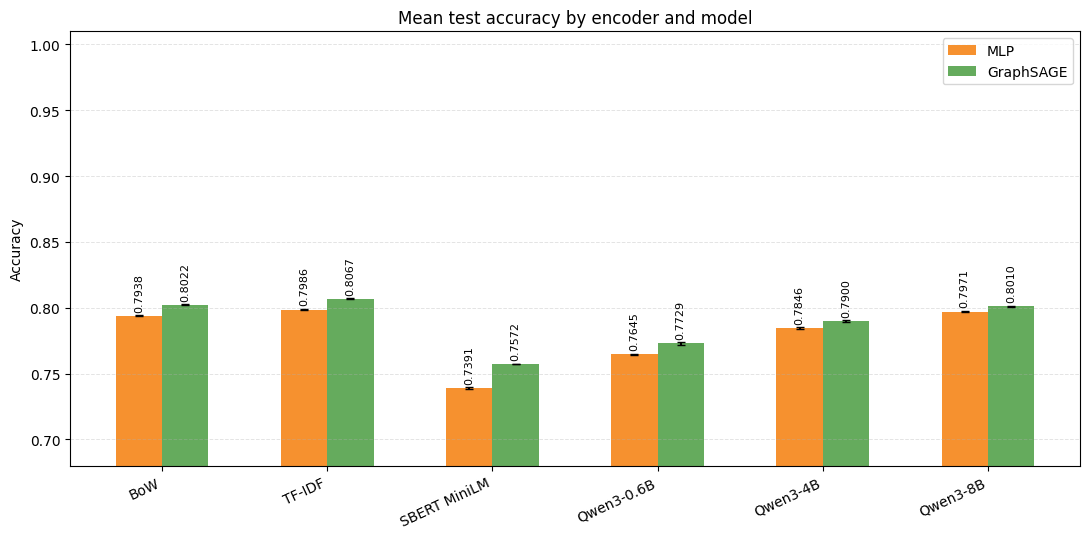

In [3]:
def add_bar_labels(ax, bars, digits=4, rotation=0):
    for bar in bars:
        value = bar.get_height()
        if value is None or (isinstance(value, float) and math.isnan(value)):
            continue
        ax.annotate(
            f'{value:.{digits}f}',
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=rotation,
        )


def plot_grouped_accuracy():
    fig, ax = plt.subplots(figsize=(11, 5.5))
    x = list(range(len(encoders)))
    width = min(0.28, 0.78 / max(1, len(models)))
    for i, model in enumerate(models):
        offset = (i - (len(models) - 1) / 2) * width
        vals = [lookup.get((model, enc), {}).get('mean_test_accuracy', 0.0) or 0.0 for enc in encoders]
        errs = [lookup.get((model, enc), {}).get('ci95', 0.0) or 0.0 for enc in encoders]
        bars = ax.bar(
            [pos + offset for pos in x],
            vals,
            width=width,
            yerr=errs,
            capsize=3,
            label=MODEL_LABEL[model],
            color=MODEL_COLOR[model],
            alpha=0.9,
        )
        add_bar_labels(ax, bars, digits=4, rotation=90)
    ax.set_title('Mean test accuracy by encoder and model')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels([ENCODER_LABEL[e] for e in encoders], rotation=25, ha='right')
    ax.set_ylim(0.68, 1.01)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_grouped_accuracy()

## Mean test accuracy by model

One standalone plot per model, comparing encoders within that model.

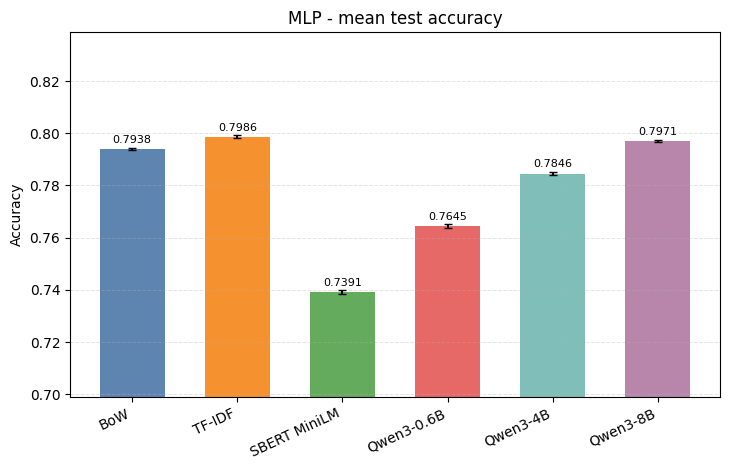

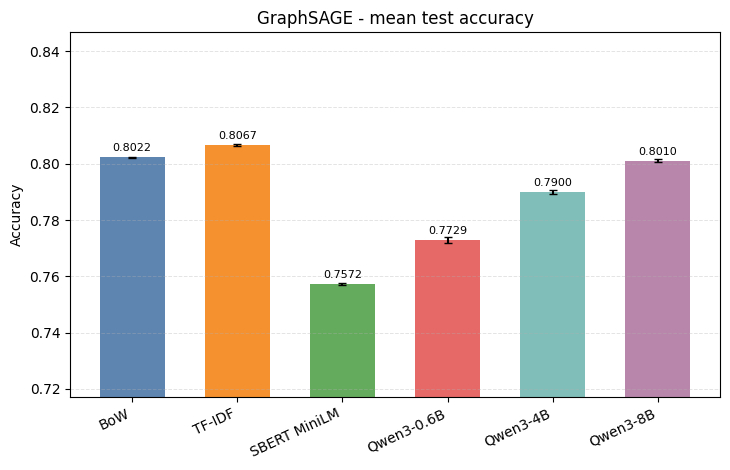

In [4]:
def plot_accuracy_by_model():
    for model in models:
        model_encoders = [enc for enc in encoders if (model, enc) in lookup]
        vals = [lookup[(model, enc)].get('mean_test_accuracy', 0.0) or 0.0 for enc in model_encoders]
        errs = [lookup[(model, enc)].get('ci95', 0.0) or 0.0 for enc in model_encoders]
        colors = [ENCODER_COLOR.get(enc, '#777777') for enc in model_encoders]
        fig, ax = plt.subplots(figsize=(7.4, 4.8))
        bars = ax.bar(range(len(model_encoders)), vals, yerr=errs, capsize=3, color=colors, alpha=0.9, width=0.62)
        add_bar_labels(ax, bars, digits=4, rotation=0)
        ax.set_title(f'{MODEL_LABEL[model]} - mean test accuracy')
        ax.set_ylabel('Accuracy')
        ax.set_xticks(range(len(model_encoders)))
        ax.set_xticklabels([ENCODER_LABEL[e] for e in model_encoders], rotation=25, ha='right')
        y_min = max(0, min(vals) - 0.04) if vals else 0
        y_max = min(1.02, max(vals) + 0.04) if vals else 1
        ax.set_ylim(y_min, y_max)
        ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
        fig.tight_layout()
        plt.show()


plot_accuracy_by_model()

## Seed-level stability

Box plots and points show the per-seed `test_acc` values for each encoder.

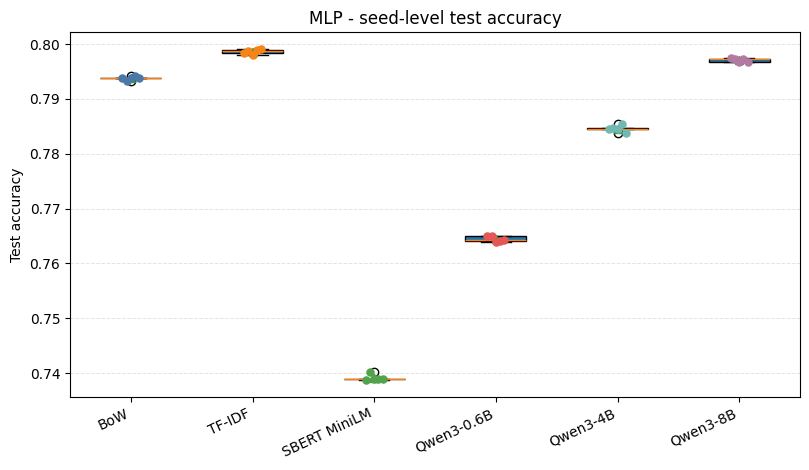

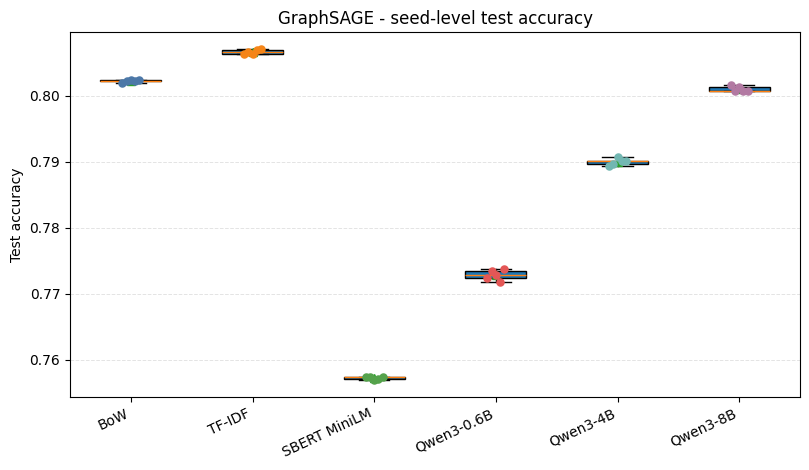

In [5]:
def plot_seed_stability():
    for model in models:
        model_encoders = [enc for enc in encoders if (model, enc) in lookup]
        data = []
        for enc in model_encoders:
            seed_values = [r.get('test_acc') for r in lookup[(model, enc)]['per_seed_results'] if r.get('test_acc') is not None]
            data.append(seed_values)
        fig, ax = plt.subplots(figsize=(8.2, 4.8))
        ax.boxplot(data, positions=list(range(len(data))), widths=0.5, patch_artist=True, showmeans=True)
        for i, values in enumerate(data):
            n = len(values)
            for j, value in enumerate(values):
                jitter = (j - (n - 1) / 2) * 0.035 if n else 0
                ax.scatter(i + jitter, value, color=ENCODER_COLOR.get(model_encoders[i], '#555555'), s=26, zorder=3)
        ax.set_title(f'{MODEL_LABEL[model]} - seed-level test accuracy')
        ax.set_ylabel('Test accuracy')
        ax.set_xticks(range(len(model_encoders)))
        ax.set_xticklabels([ENCODER_LABEL[e] for e in model_encoders], rotation=25, ha='right')
        ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
        fig.tight_layout()
        plt.show()


plot_seed_stability()

## Train / validation / test accuracy

These plots compare the mean per-seed train, validation, and test accuracy for each encoder.

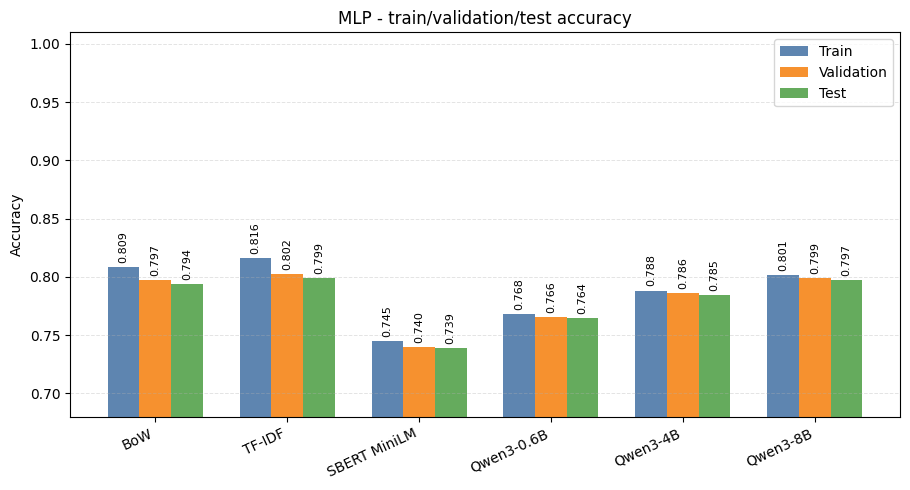

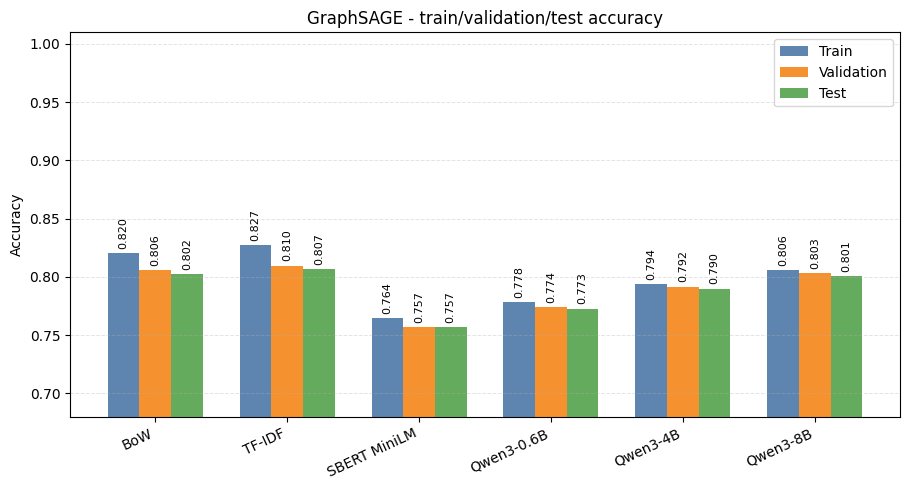

In [6]:
def plot_split_accuracy():
    split_fields = [('mean_train_acc', 'Train'), ('mean_val_acc', 'Validation'), ('mean_test_accuracy', 'Test')]
    split_colors = ['#4c78a8', '#f58518', '#54a24b']
    for model in models:
        model_encoders = [enc for enc in encoders if (model, enc) in lookup]
        x = list(range(len(model_encoders)))
        width = 0.24
        fig, ax = plt.subplots(figsize=(9.2, 5.0))
        for i, (field, label) in enumerate(split_fields):
            offset = (i - 1) * width
            vals = [lookup[(model, enc)].get(field, 0.0) or 0.0 for enc in model_encoders]
            bars = ax.bar([pos + offset for pos in x], vals, width=width, label=label, color=split_colors[i], alpha=0.9)
            add_bar_labels(ax, bars, digits=3, rotation=90)
        ax.set_title(f'{MODEL_LABEL[model]} - train/validation/test accuracy')
        ax.set_ylabel('Accuracy')
        ax.set_xticks(x)
        ax.set_xticklabels([ENCODER_LABEL[e] for e in model_encoders], rotation=25, ha='right')
        ax.set_ylim(0.68, 1.01)
        ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)
        ax.legend()
        fig.tight_layout()
        plt.show()


plot_split_accuracy()

## Checkpoint and loss statistics

Mean best epoch and mean test loss are computed from `per_seed_results`.

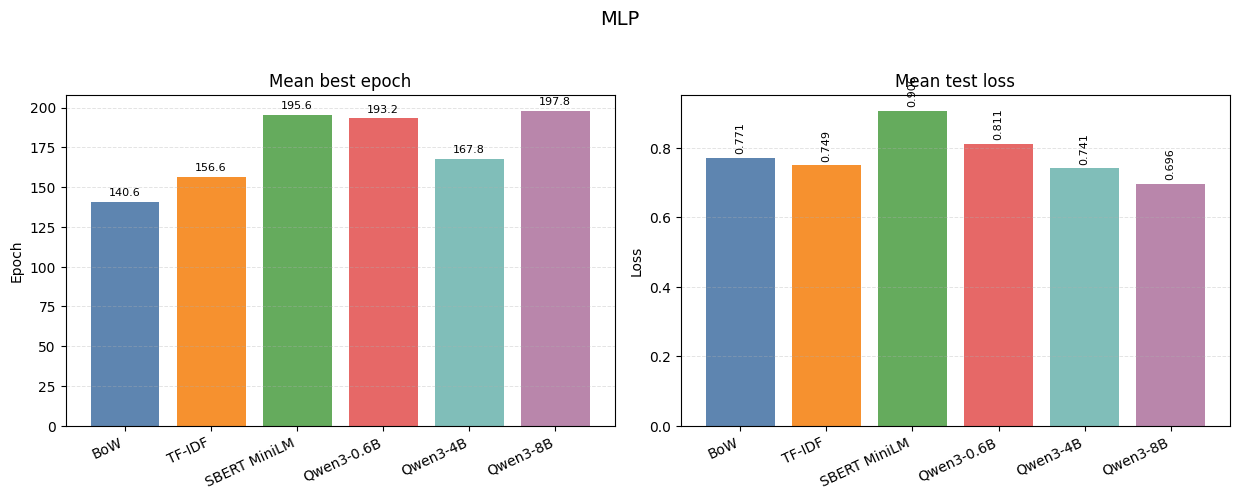

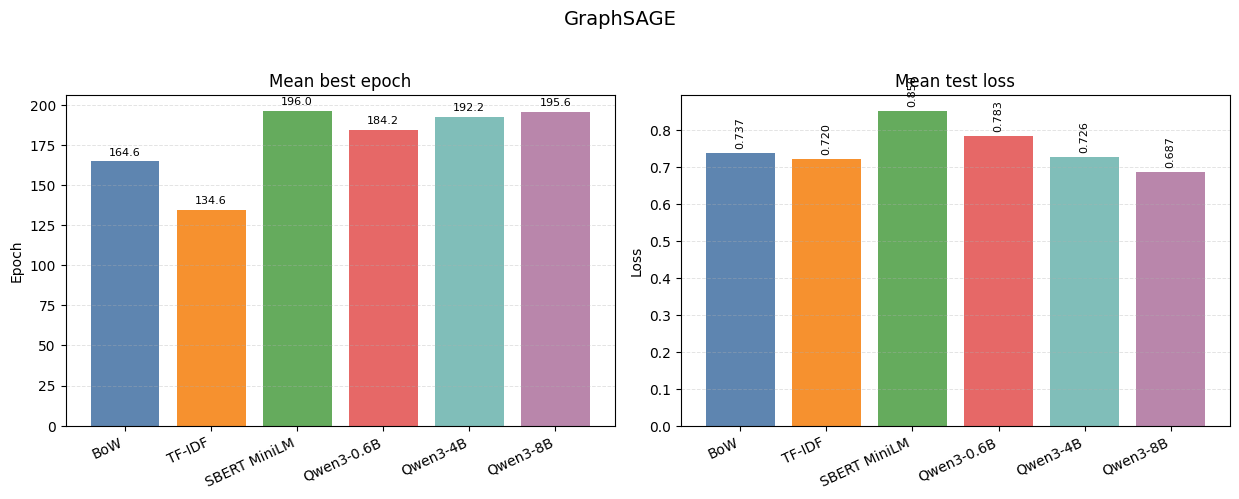

In [7]:
def plot_checkpoint_and_loss():
    for model in models:
        model_encoders = [enc for enc in encoders if (model, enc) in lookup]
        labels = [ENCODER_LABEL[e] for e in model_encoders]
        colors = [ENCODER_COLOR.get(e, '#777777') for e in model_encoders]
        x = list(range(len(model_encoders)))
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

        epochs = [lookup[(model, enc)].get('mean_best_epoch', 0.0) or 0.0 for enc in model_encoders]
        bars = axes[0].bar(x, epochs, color=colors, alpha=0.9)
        add_bar_labels(axes[0], bars, digits=1, rotation=0)
        axes[0].set_title('Mean best epoch')
        axes[0].set_ylabel('Epoch')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(labels, rotation=25, ha='right')
        axes[0].grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)

        losses = [lookup[(model, enc)].get('mean_test_loss', 0.0) or 0.0 for enc in model_encoders]
        bars = axes[1].bar(x, losses, color=colors, alpha=0.9)
        add_bar_labels(axes[1], bars, digits=3, rotation=90)
        axes[1].set_title('Mean test loss')
        axes[1].set_ylabel('Loss')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(labels, rotation=25, ha='right')
        axes[1].grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.35)

        fig.suptitle(MODEL_LABEL[model], y=1.03, fontsize=14)
        fig.tight_layout()
        plt.show()


plot_checkpoint_and_loss()

## Embedding dimension vs accuracy

Each point is one model/encoder result.

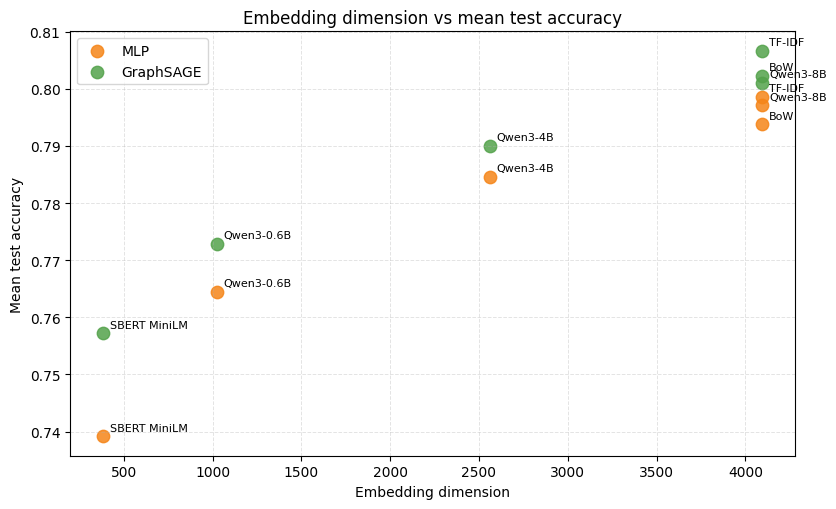

In [8]:
def plot_embedding_dim_vs_accuracy():
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for model in models:
        model_rows = [r for r in rows if r['model_key'] == model and r.get('embedding_dim') is not None]
        xs = [r['embedding_dim'] for r in model_rows]
        ys = [r['mean_test_accuracy'] for r in model_rows]
        ax.scatter(xs, ys, s=80, color=MODEL_COLOR[model], alpha=0.85, label=MODEL_LABEL[model])
        for r in model_rows:
            ax.annotate(r['encoder_label'], (r['embedding_dim'], r['mean_test_accuracy']), xytext=(5, 4), textcoords='offset points', fontsize=8)
    ax.set_title('Embedding dimension vs mean test accuracy')
    ax.set_xlabel('Embedding dimension')
    ax.set_ylabel('Mean test accuracy')
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_embedding_dim_vs_accuracy()

## Tuning results

The table lists the best validation configurations from the hyperparameter search for each model and encoder.

In [9]:
tuning_records = []
for r in rows:
    for t in r.get('tuning_results', []):
        tuning_records.append({
            'model_label': r['model_label'],
            'encoder_label': r['encoder_label'],
            'learning_rate': t.get('learning_rate'),
            'hidden_channels': t.get('hidden_channels'),
            'dropout': t.get('dropout'),
            'best_epoch': t.get('best_epoch'),
            'val_acc': t.get('val_acc'),
            'test_acc': t.get('test_acc'),
            'val_loss': t.get('val_loss'),
            'test_loss': t.get('test_loss'),
        })

top_tuning = sorted(tuning_records, key=lambda r: r.get('val_acc') or -1, reverse=True)[:20]
headers = ['Rank', 'Model', 'Encoder', 'LR', 'Hidden', 'Dropout', 'Best epoch', 'Val acc', 'Test acc', 'Val loss']
records = []
for i, r in enumerate(top_tuning, start=1):
    records.append([
        i,
        r['model_label'],
        r['encoder_label'],
        r['learning_rate'],
        r['hidden_channels'],
        r['dropout'],
        r['best_epoch'],
        fmt(r['val_acc']),
        fmt(r['test_acc']),
        fmt(r['val_loss']),
    ])
print_table(headers, records)

Rank | Model     | Encoder  | LR    | Hidden | Dropout | Best epoch | Val acc | Test acc | Val loss
-----+-----------+----------+-------+--------+---------+------------+---------+----------+---------
1    | GraphSAGE | TF-IDF   | 0.01  | 256    | 0.2     | 177        | 0.8098  | 0.8071   | 0.7129  
2    | GraphSAGE | TF-IDF   | 0.01  | 256    | 0.5     | 155        | 0.8095  | 0.8062   | 0.7176  
3    | GraphSAGE | TF-IDF   | 0.01  | 128    | 0.2     | 156        | 0.8093  | 0.8063   | 0.7198  
4    | GraphSAGE | TF-IDF   | 0.01  | 128    | 0.5     | 186        | 0.8083  | 0.8059   | 0.7264  
5    | GraphSAGE | TF-IDF   | 0.005 | 256    | 0.5     | 190        | 0.8081  | 0.8058   | 0.7265  
6    | GraphSAGE | TF-IDF   | 0.005 | 256    | 0.2     | 187        | 0.8079  | 0.8060   | 0.7221  
7    | GraphSAGE | TF-IDF   | 0.005 | 128    | 0.2     | 200        | 0.8063  | 0.8044   | 0.7354  
8    | GraphSAGE | TF-IDF   | 0.005 | 128    | 0.5     | 200        | 0.8056  | 0.8030   | 0.7455  


## Winners

A compact summary of the strongest results.

In [10]:
best_overall = max(rows, key=lambda r: r.get('mean_test_accuracy') or -1)
print(f"Best overall: {best_overall['model_label']} + {best_overall['encoder_label']} = {best_overall['mean_test_accuracy']:.4f}")
for model in models:
    best = max([r for r in rows if r['model_key'] == model], key=lambda r: r.get('mean_test_accuracy') or -1)
    print(f"Best {MODEL_LABEL[model]}: {best['encoder_label']} = {best['mean_test_accuracy']:.4f} +/- {best.get('ci95', 0.0):.5f}")

Best overall: GraphSAGE + TF-IDF = 0.8067
Best MLP: TF-IDF = 0.7986 +/- 0.00052
Best GraphSAGE: TF-IDF = 0.8067 +/- 0.00042
